In [5]:
"""Tabular baseline notebook using shared src preprocessing + model helpers."""

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Ensure src is on path for shared constants and helpers
ROOT = Path.cwd().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

NOTEBOOK_DIR = Path.cwd()
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
CHECKPOINT_DIR = ARTIFACT_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACT_ROOT / "results"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
CONFIG_SNAPSHOT_PATH = RESULTS_DIR / "config.json"
for _p in (ARTIFACT_ROOT, CHECKPOINT_DIR, RESULTS_DIR, PLOTS_DIR):
    _p.mkdir(parents=True, exist_ok=True)

from data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
import data.encode_features as enc
from models.train import TrainConfig, make_loaders, train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Shared model defaults used throughout this notebook
ENCODER_HIDDEN = (256, 128, 64)
HEAD_HIDDEN = ()
DROPOUT = 0.1
LR = 1e-3

## Notebook Overview
- Build tabular baseline using shared preprocessing and model helpers from `src`.
- Save artifacts under `notebooks/artifacts/baseline/` (`checkpoints`, `results`, `plots`).
- Train shared tabular regressor, log metrics, and export model/config/results for reuse.

In [6]:
# Load processed splits and build feature matrices
from torch.utils.data import DataLoader, TensorDataset

data_dir = ROOT / "data" / "processed" / "all_features"

train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

(
    X_train_np,
    X_val_np,
    X_test_np,
    y_train_np,
    y_val_np,
    y_test_np,
    artifacts,
) = enc.prepare_features(train_df, val_df, test_df)

input_dim = X_train_np.shape[1]
print(f"Input dim (shared): {input_dim}")
print(f"Train/val/test shapes: {X_train_np.shape}, {X_val_np.shape}, {X_test_np.shape}")

# Build loaders for shared (concatenated) features
batch_size = 256
train_loader, val_loader = make_loaders(
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=batch_size,
    separate=False,
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np)),
    batch_size=batch_size,
    shuffle=False,
)

Input dim (shared): 12
Train/val/test shapes: (3804, 12), (815, 12), (816, 12)


In [7]:
# --- Cell: Early stopping + scheduler support inside train_model (same API) ---

from dataclasses import dataclass
from copy import deepcopy
import numpy as np
import torch

from models.model import TabularRegressor

@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True

@dataclass
class SchedConfig:
    # ReduceLROnPlateau (safe default for tabular)
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4

def _set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 0.0):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = float("inf")
        self.bad = 0

    def step(self, current: float) -> bool:
        # returns True if should stop
        if current < (self.best - self.min_delta):
            self.best = current
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience


# --- Patch train_model WITHOUT changing its signature (same API) ---
# Assumptions about your existing train_model:
# - It already builds: model, optimizer, loss_fn
# - It already runs epochs and returns (model, history_dict with "val_loss")
#
# Below is a drop-in version you can paste OVER your current train_model
# or adapt by copying only the early-stopping parts.

def train_model(cfg, train_loader, val_loader, X_is_separate: bool = False):
    """
    Same API as your notebook currently uses:
      model_tmp, history_tmp = train_model(cfg, train_loader, val_loader, X_is_separate=False)

    Requires cfg fields (existing): mode, input_dim/num_dim/cat_dim, encoder_hidden, head_hidden,
                                   dropout, lr, epochs, batch_size, device
    Adds optional fields (safe if missing): weight_decay, seed, early_stop, scheduler
    """
    device = torch.device(cfg.device)

    # Optional: seed
    seed = getattr(cfg, "seed", None)
    if seed is not None:
        _set_seed(int(seed))

    # --- Build model (use YOUR existing model constructor here) ---
    # Example (adapt to your notebook):
    model = TabularRegressor(
        mode=cfg.mode,
        input_dim=getattr(cfg, "input_dim", None),
        num_dim=getattr(cfg, "num_dim", None),
        cat_dim=getattr(cfg, "cat_dim", None),
        encoder_hidden=cfg.encoder_hidden,
        head_hidden=cfg.head_hidden,
        dropout=cfg.dropout,
    ).to(device)

    # --- Optimizer (AdamW recommended when weight_decay is used) ---
    weight_decay = float(getattr(cfg, "weight_decay", 0.0))
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=weight_decay)

    # --- Loss ---
    loss_fn = torch.nn.MSELoss()

    # --- Optional scheduler (ReduceLROnPlateau) ---
    sched_cfg = getattr(cfg, "scheduler", None)
    if sched_cfg is None:
        sched_cfg = SchedConfig()  # default on
    if isinstance(sched_cfg, dict):
        sched_cfg = SchedConfig(**sched_cfg)

    scheduler = None
    if sched_cfg.enabled:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=sched_cfg.mode,
            factor=sched_cfg.factor,
            patience=sched_cfg.patience,
            min_lr=sched_cfg.min_lr,
            threshold=sched_cfg.threshold,
        )

    # --- Optional early stopping ---
    es_cfg = getattr(cfg, "early_stop", None)
    if es_cfg is None:
        es_cfg = EarlyStopConfig()  # default on
    if isinstance(es_cfg, dict):
        es_cfg = EarlyStopConfig(**es_cfg)

    early_stopper = EarlyStopping(patience=es_cfg.patience, min_delta=es_cfg.min_delta)

    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [], "lr": []}
    best_state = None
    best_epoch = 0
    best_val = float("inf")

    def _forward_batch(batch):
        # Adapt this part to your existing batch format.
        # Common patterns:
        # 1) shared: batch = (x, y)
        # 2) separate (from make_loaders): batch = (x_num, x_cat, y)
        if X_is_separate:
            x_num, x_cat, y = batch
            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            y = y.to(device)
            pred = model((x_num, x_cat))
        else:
            x, y = batch
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
        return pred, y

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_losses = []
        train_mae = []
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            pred, y = _forward_batch(batch)
            loss = loss_fn(pred.squeeze(), y.squeeze())
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_mae.append(torch.mean(torch.abs(pred.squeeze() - y.squeeze())).item())

        train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
        train_mae_val = float(np.mean(train_mae)) if train_mae else float("nan")

        model.eval()
        val_losses = []
        val_mae = []
        with torch.no_grad():
            for batch in val_loader:
                pred, y = _forward_batch(batch)
                loss = loss_fn(pred.squeeze(), y.squeeze())
                val_losses.append(loss.item())
                val_mae.append(torch.mean(torch.abs(pred.squeeze() - y.squeeze())).item())
        val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
        val_mae_val = float(np.mean(val_mae)) if val_mae else float("nan")

        # Scheduler step (plateau uses val metric)
        if scheduler is not None and np.isfinite(val_loss):
            scheduler.step(val_loss)

        # Track LR
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae_val)
        history["val_mae"].append(val_mae_val)
        history["lr"].append(float(optimizer.param_groups[0]["lr"]))

        # Save best
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

        # Early stop
        if np.isfinite(val_loss) and early_stopper.step(val_loss):
            break

    if es_cfg.restore_best and best_state is not None:
        model.load_state_dict(best_state)

    # (Optional) attach best info for convenience
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val

    return model, history


In [8]:
# --- Cell: Comprehensive grid search (Stage A + Stage B) with early stopping, same outer API ---

import pandas as pd
import numpy as np
import torch

# Stage A (broad, early-stopped)
grid = {
    "encoder_hidden": [
        (128,),
        (256, 128),
        (256, 256),
        (256, 128, 64),
        (512, 256),
        (512, 512),
        (512, 256, 128),
        (512, 256, 128, 64),
    ],
    "dropout": [0.0, 0.1, 0.2],
    "lr": [3e-3, 1e-3, 3e-4],
    "weight_decay": [0.0, 1e-5, 1e-4, 1e-3],
}

fixed_epochs = 100
fixed_batch_size = batch_size

EARLY_STOP = EarlyStopConfig(patience=25, min_delta=0.0, restore_best=True)
SCHED = SchedConfig(enabled=True, factor=0.5, patience=8, min_lr=1e-6, threshold=1e-4)

grid_results = []
best_config = None
best_val_mse = float("inf")

run_id = 0
for encoder_hidden in grid["encoder_hidden"]:
    for dropout in grid["dropout"]:
        for lr in grid["lr"]:
            for wd in grid["weight_decay"]:
                run_id += 1

                cfg = TrainConfig(
                    mode="shared",
                    input_dim=input_dim,
                    encoder_hidden=encoder_hidden,
                    head_hidden=HEAD_HIDDEN,
                    dropout=dropout,
                    lr=lr,
                    epochs=fixed_epochs,
                    batch_size=fixed_batch_size,
                    device=str(device),
                )

                # Add optional fields (doesn't change external API usage)
                cfg.weight_decay = wd
                cfg.early_stop = EARLY_STOP
                cfg.scheduler = SCHED
                cfg.seed = 0  # fixed seed for Stage A ranking

                print(
                    f"[A {run_id}] encoder_hidden={encoder_hidden}, dropout={dropout}, lr={lr}, wd={wd}"
                )

                model_tmp, history_tmp = train_model(
                    cfg, train_loader, val_loader, X_is_separate=False
                )

                best_epoch = int(history_tmp.get("best_epoch", int(np.argmin(history_tmp["val_loss"])) + 1))
                best_val = float(history_tmp.get("best_val_loss", np.min(history_tmp["val_loss"])))
                last_epoch = len(history_tmp["val_loss"])

                grid_results.append(
                    {
                        "stage": "A",
                        "encoder_hidden": encoder_hidden,
                        "depth": len(encoder_hidden),
                        "dropout": dropout,
                        "lr": lr,
                        "weight_decay": wd,
                        "seed": getattr(cfg, "seed", None),
                        "best_val_mse": best_val,
                        "best_epoch": best_epoch,
                        "epochs_ran": last_epoch,
                    }
                )

                if best_val < best_val_mse:
                    best_val_mse = best_val
                    best_config = cfg

                del model_tmp
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

grid_results_df = pd.DataFrame(grid_results).sort_values("best_val_mse")
stageA_path = RESULTS_DIR / "grid_search_stageA.csv"
grid_results_df.to_csv(stageA_path, index=False)

display(grid_results_df.head(15))
print(f"Saved Stage A results to {stageA_path}")
print(f"Stage A best config (single seed ranking): {best_config}")


[A 1] encoder_hidden=(128,), dropout=0.0, lr=0.003, wd=0.0
[A 2] encoder_hidden=(128,), dropout=0.0, lr=0.003, wd=1e-05
[A 3] encoder_hidden=(128,), dropout=0.0, lr=0.003, wd=0.0001
[A 4] encoder_hidden=(128,), dropout=0.0, lr=0.003, wd=0.001
[A 5] encoder_hidden=(128,), dropout=0.0, lr=0.001, wd=0.0
[A 6] encoder_hidden=(128,), dropout=0.0, lr=0.001, wd=1e-05
[A 7] encoder_hidden=(128,), dropout=0.0, lr=0.001, wd=0.0001
[A 8] encoder_hidden=(128,), dropout=0.0, lr=0.001, wd=0.001
[A 9] encoder_hidden=(128,), dropout=0.0, lr=0.0003, wd=0.0
[A 10] encoder_hidden=(128,), dropout=0.0, lr=0.0003, wd=1e-05
[A 11] encoder_hidden=(128,), dropout=0.0, lr=0.0003, wd=0.0001
[A 12] encoder_hidden=(128,), dropout=0.0, lr=0.0003, wd=0.001
[A 13] encoder_hidden=(128,), dropout=0.1, lr=0.003, wd=0.0
[A 14] encoder_hidden=(128,), dropout=0.1, lr=0.003, wd=1e-05
[A 15] encoder_hidden=(128,), dropout=0.1, lr=0.003, wd=0.0001
[A 16] encoder_hidden=(128,), dropout=0.1, lr=0.003, wd=0.001
[A 17] encoder_hi

,stage,encoder_hidden,depth,dropout,lr,weight_decay,seed,best_val_mse,best_epoch,epochs_ran
267,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00100,0,1.062354,28,53
266,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00010,0,1.063199,28,53
264,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00000,0,1.065090,28,53
232,A,"(512, 256, 128)",3,0.1,0.001,0.00000,0,1.065250,77,102
233,A,"(512, 256, 128)",3,0.1,0.001,0.00001,0,1.065250,77,102
265,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00001,0,1.065712,28,53
234,A,"(512, 256, 128)",3,0.1,0.001,0.00010,0,1.067101,68,93
235,A,"(512, 256, 128)",3,0.1,0.001,0.00100,0,1.068392,77,102
150,A,"(512, 256)",2,0.0,0.001,0.00010,0,1.068655,45,70
151,A,"(512, 256)",2,0.0,0.001,0.00100,0,1.068902,45,70


Saved Stage A results to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\grid_search_stageA.csv
Stage A best config (single seed ranking): TrainConfig(mode='shared', input_dim=12, num_dim=None, cat_dim=None, encoder_hidden=(512, 256, 128, 64), head_hidden=(), dropout=0.1, lr=0.003, epochs=200, batch_size=256, device='cpu', freeze_encoder_epochs=0)


In [9]:
# --- Cell: Stage B (top-k configs, multi-seed) + clear outputs ---

TOP_K = 10
SEEDS = [0, 1, 2]

topA = grid_results_df.head(TOP_K).copy()

confirm_rows = []
for i, row in topA.iterrows():
    enc = row["encoder_hidden"]
    dr = float(row["dropout"])
    lr = float(row["lr"])
    wd = float(row["weight_decay"])

    for seed in SEEDS:
        cfg = TrainConfig(
            mode="shared",
            input_dim=input_dim,
            encoder_hidden=enc,
            head_hidden=HEAD_HIDDEN,
            dropout=dr,
            lr=lr,
            epochs=fixed_epochs,
            batch_size=fixed_batch_size,
            device=str(device),
        )
        cfg.weight_decay = wd
        cfg.early_stop = EARLY_STOP
        cfg.scheduler = SCHED
        cfg.seed = seed

        print(f"[B] enc={enc}, dr={dr}, lr={lr}, wd={wd}, seed={seed}")
        model_tmp, history_tmp = train_model(cfg, train_loader, val_loader, X_is_separate=False)

        best_epoch = int(history_tmp.get("best_epoch", int(np.argmin(history_tmp["val_loss"])) + 1))
        best_val = float(history_tmp.get("best_val_loss", np.min(history_tmp["val_loss"])))
        last_epoch = len(history_tmp["val_loss"])

        confirm_rows.append(
            {
                "stage": "B",
                "encoder_hidden": enc,
                "depth": len(enc),
                "dropout": dr,
                "lr": lr,
                "weight_decay": wd,
                "seed": seed,
                "best_val_mse": best_val,
                "best_epoch": best_epoch,
                "epochs_ran": last_epoch,
            }
        )

        del model_tmp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

confirm_df = pd.DataFrame(confirm_rows)

# Aggregate across seeds
agg = (
    confirm_df.groupby(["encoder_hidden", "dropout", "lr", "weight_decay", "depth"], dropna=False)
    .agg(
        mean_best_val_mse=("best_val_mse", "mean"),
        std_best_val_mse=("best_val_mse", "std"),
        mean_best_epoch=("best_epoch", "mean"),
        mean_epochs_ran=("epochs_ran", "mean"),
    )
    .reset_index()
    .sort_values("mean_best_val_mse")
)

stageB_raw_path = RESULTS_DIR / "grid_search_stageB_raw.csv"
stageB_agg_path = RESULTS_DIR / "grid_search_stageB_agg.csv"
confirm_df.to_csv(stageB_raw_path, index=False)
agg.to_csv(stageB_agg_path, index=False)

# Clear outputs
print("\n=== Stage A: Top 10 (single-seed) ===")
display(grid_results_df.head(10))

print("\n=== Stage B: Top configs aggregated over seeds ===")
display(agg.head(15))

# Use the multi-seed winner for the final training cell
best_row = agg.iloc[0].to_dict()
enc = best_row["encoder_hidden"]
if isinstance(enc, str):
    enc = eval(enc)

best_config = TrainConfig(
    mode="shared",
    input_dim=input_dim,
    encoder_hidden=enc,
    head_hidden=HEAD_HIDDEN,
    dropout=float(best_row["dropout"]),
    lr=float(best_row["lr"]),
    epochs=fixed_epochs,
    batch_size=fixed_batch_size,
    device=str(device),
)
best_config.weight_decay = float(best_row["weight_decay"])
best_config.early_stop = EARLY_STOP
best_config.scheduler = SCHED
best_config.seed = 0

print("\n=== Best (by mean over seeds) ===")
for k in ["encoder_hidden", "dropout", "lr", "weight_decay", "depth", "mean_best_val_mse", "std_best_val_mse", "mean_best_epoch"]:
    print(f"{k}: {best_row[k]}")

print(f"\nSaved Stage B raw to {stageB_raw_path}")
print(f"Saved Stage B agg  to {stageB_agg_path}")


[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.001, seed=0
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.001, seed=1
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.001, seed=2
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0001, seed=0
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0001, seed=1
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0001, seed=2
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0, seed=0
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0, seed=1
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=0.0, seed=2
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=0.0, seed=0
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=0.0, seed=1
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=0.0, seed=2
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=1e-05, seed=0
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=1e-05, seed=1
[B] enc=(512, 256, 128), dr=0.1, lr=0.001, wd=1e-05, seed=2
[B] enc=(512, 256, 128, 64), dr=0.1, lr=0.003, wd=1e-05, seed=0
[B] enc=(

,stage,encoder_hidden,depth,dropout,lr,weight_decay,seed,best_val_mse,best_epoch,epochs_ran
267,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00100,0,1.062354,28,53
266,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00010,0,1.063199,28,53
264,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00000,0,1.065090,28,53
232,A,"(512, 256, 128)",3,0.1,0.001,0.00000,0,1.065250,77,102
233,A,"(512, 256, 128)",3,0.1,0.001,0.00001,0,1.065250,77,102
265,A,"(512, 256, 128, 64)",4,0.1,0.003,0.00001,0,1.065712,28,53
234,A,"(512, 256, 128)",3,0.1,0.001,0.00010,0,1.067101,68,93
235,A,"(512, 256, 128)",3,0.1,0.001,0.00100,0,1.068392,77,102
150,A,"(512, 256)",2,0.0,0.001,0.00010,0,1.068655,45,70
151,A,"(512, 256)",2,0.0,0.001,0.00100,0,1.068902,45,70



=== Stage B: Top configs aggregated over seeds ===


,encoder_hidden,dropout,lr,weight_decay,depth,mean_best_val_mse,std_best_val_mse,mean_best_epoch,mean_epochs_ran
8,"(512, 256, 128, 64)",0.1,0.003,0.00010,4,1.073222,0.011011,45.666667,70.666667
7,"(512, 256, 128, 64)",0.1,0.003,0.00001,4,1.073357,0.010023,45.666667,70.666667
6,"(512, 256, 128, 64)",0.1,0.003,0.00000,4,1.074908,0.009725,45.666667,70.666667
9,"(512, 256, 128, 64)",0.1,0.003,0.00100,4,1.075198,0.014381,45.666667,70.666667
3,"(512, 256, 128)",0.1,0.001,0.00001,3,1.076797,0.013891,77.000000,102.000000
2,"(512, 256, 128)",0.1,0.001,0.00000,3,1.076797,0.013891,77.000000,102.000000
4,"(512, 256, 128)",0.1,0.001,0.00010,3,1.077406,0.012434,74.000000,99.000000
5,"(512, 256, 128)",0.1,0.001,0.00100,3,1.080456,0.011058,77.000000,102.000000
0,"(512, 256)",0.0,0.001,0.00010,2,1.091539,0.021995,56.333333,81.333333
1,"(512, 256)",0.0,0.001,0.00100,2,1.092690,0.022133,56.333333,81.333333



=== Best (by mean over seeds) ===
encoder_hidden: (512, 256, 128, 64)
dropout: 0.1
lr: 0.003
weight_decay: 0.0001
depth: 4
mean_best_val_mse: 1.0732222944498062
std_best_val_mse: 0.011010689825138262
mean_best_epoch: 45.666666666666664

Saved Stage B raw to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\grid_search_stageB_raw.csv
Saved Stage B agg  to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\grid_search_stageB_agg.csv


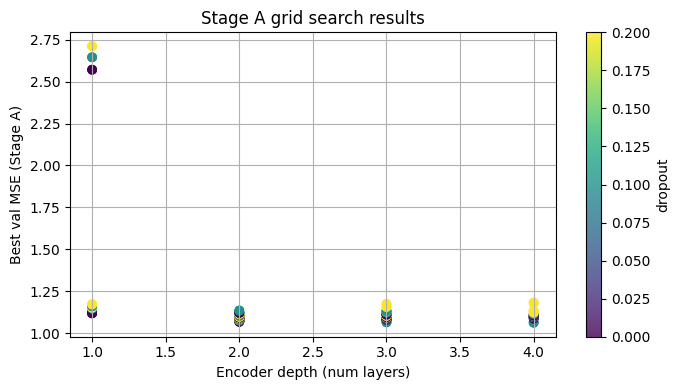

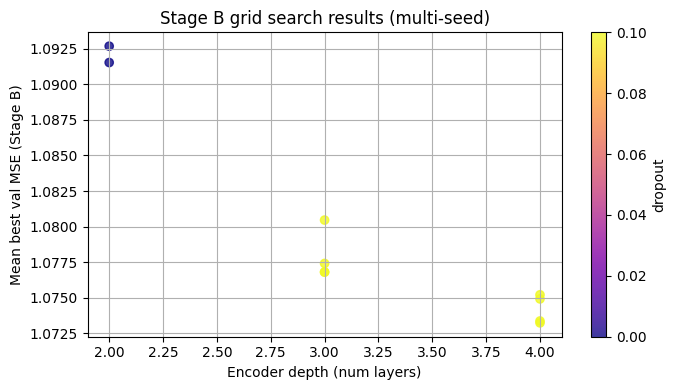

In [10]:
# --- Cell: Grid search plots (Stage A + Stage B) ---

import matplotlib.pyplot as plt

# Stage A plot (single-seed ranking)
if "grid_results_df" in globals():
    plt.figure(figsize=(7, 4))
    plt.scatter(
        grid_results_df["depth"],
        grid_results_df["best_val_mse"],
        c=grid_results_df["dropout"],
        cmap="viridis",
        alpha=0.8,
    )
    plt.colorbar(label="dropout")
    plt.xlabel("Encoder depth (num layers)")
    plt.ylabel("Best val MSE (Stage A)")
    plt.title("Stage A grid search results")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Stage B plot (multi-seed aggregated)
if "agg" in globals():
    plt.figure(figsize=(7, 4))
    plt.scatter(
        agg["depth"],
        agg["mean_best_val_mse"],
        c=agg["dropout"],
        cmap="plasma",
        alpha=0.8,
    )
    plt.colorbar(label="dropout")
    plt.xlabel("Encoder depth (num layers)")
    plt.ylabel("Mean best val MSE (Stage B)")
    plt.title("Stage B grid search results (multi-seed)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
# # Grid search over shared tabular hyperparameters (including depth)
# # Note: expand/shrink the grid to balance quality vs. runtime.
# grid = {
#     "encoder_hidden": [
#         (128,),
#         (256, 128),
#         (256, 128, 64),
#         (512, 256),
#         (512, 256, 128),
#         (512, 256, 128, 64),
#     ],
#     "dropout": [0.0, 0.05, 0.1, 0.2],
#     "lr": [3e-3, 1e-3, 3e-4, 1e-4],
# }
# fixed_epochs = 200
# fixed_batch_size = batch_size

# grid_results = []
# best_config = None
# best_val_mse = float("inf")

# for encoder_hidden in grid["encoder_hidden"]:
#     for dropout in grid["dropout"]:
#         for lr in grid["lr"]:
#             cfg = TrainConfig(
#                 mode="shared",
#                 input_dim=input_dim,
#                 encoder_hidden=encoder_hidden,
#                 head_hidden=HEAD_HIDDEN,
#                 dropout=dropout,
#                 lr=lr,
#                 epochs=fixed_epochs,
#                 batch_size=fixed_batch_size,
#                 device=str(device),
#             )
#             print(
#                 "Training config: "
#                 f"encoder_hidden={encoder_hidden}, dropout={dropout}, lr={lr}"
#             )
#             model_tmp, history_tmp = train_model(
#                 cfg, train_loader, val_loader, X_is_separate=False
#             )
#             best_epoch = int(np.argmin(history_tmp["val_loss"])) + 1
#             best_val = float(np.min(history_tmp["val_loss"]))
#             grid_results.append(
#                 {
#                     "encoder_hidden": encoder_hidden,
#                     "depth": len(encoder_hidden),
#                     "dropout": dropout,
#                     "lr": lr,
#                     "best_val_mse": best_val,
#                     "best_epoch": best_epoch,
#                 }
#             )
#             if best_val < best_val_mse:
#                 best_val_mse = best_val
#                 best_config = cfg

#             del model_tmp
#             if torch.cuda.is_available():
#                 torch.cuda.empty_cache()

# grid_results_df = pd.DataFrame(grid_results).sort_values("best_val_mse")
# grid_results_path = RESULTS_DIR / "grid_search.csv"
# grid_results_df.to_csv(grid_results_path, index=False)
# display(grid_results_df.head(10))
# print(f"Saved grid search results to {grid_results_path}")
# print(f"Best config: {best_config}")

In [19]:
# Train a shared tabular regressor using src/models
if "best_config" in globals() and best_config is not None:
    cfg = best_config
else:
    cfg = TrainConfig(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=ENCODER_HIDDEN,
        head_hidden=HEAD_HIDDEN,
        dropout=DROPOUT,
        lr=LR,
        epochs=200,
        batch_size=batch_size,
        device=str(device),
    )

print(f"Training final model with config: {cfg}")
print(f"Full config (incl. extras): {cfg.__dict__}")

model, history = train_model(cfg, train_loader, val_loader, X_is_separate=False)
model = model.to(device).eval()

Training final model with config: TrainConfig(mode='shared', input_dim=12, num_dim=None, cat_dim=None, encoder_hidden=(512, 256, 128, 64), head_hidden=(), dropout=0.1, lr=0.003, epochs=200, batch_size=256, device='cpu', freeze_encoder_epochs=0)
Full config (incl. extras): {'mode': 'shared', 'input_dim': 12, 'num_dim': None, 'cat_dim': None, 'encoder_hidden': (512, 256, 128, 64), 'head_hidden': (), 'dropout': 0.1, 'lr': 0.003, 'epochs': 200, 'batch_size': 256, 'device': 'cpu', 'freeze_encoder_epochs': 0, 'weight_decay': 0.0001, 'early_stop': EarlyStopConfig(patience=25, min_delta=0.0, restore_best=True), 'scheduler': SchedConfig(enabled=True, mode='min', factor=0.5, patience=8, min_lr=1e-06, threshold=0.0001), 'seed': 0}


In [13]:
# Inspect model architecture and size
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_bytes = sum(p.numel() * p.element_size() for p in model.state_dict().values())
size_mb = size_bytes / (1024 * 1024)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Checkpoint size (approx): {size_mb:.2f} MB")

TabularRegressor(
  (encoder): SharedTabularEncoder(
    (net): Sequential(
      (0): Linear(in_features=12, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=256, out_features=128, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.1, inplace=False)
      (9): Linear(in_features=128, out_features=64, bias=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
  )
  (head): RegressionHead(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Total parameters: 179,201
Trainable parameters: 179,201
Checkpoint size (approx): 0.68 MB


In [14]:
# Evaluate on test set (MSE and MAE)
loss_fn = torch.nn.MSELoss()
test_loss = 0.0
test_mae = 0.0
test_steps = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb).unsqueeze(1)
        test_loss += loss_fn(pred, yb.unsqueeze(1)).item()
        test_mae += torch.abs(pred - yb.unsqueeze(1)).mean().item()
        test_steps += 1

test_loss /= max(test_steps, 1)
test_mae /= max(test_steps, 1)
print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

Test MSE: 1.0420 | Test MAE: 0.7098


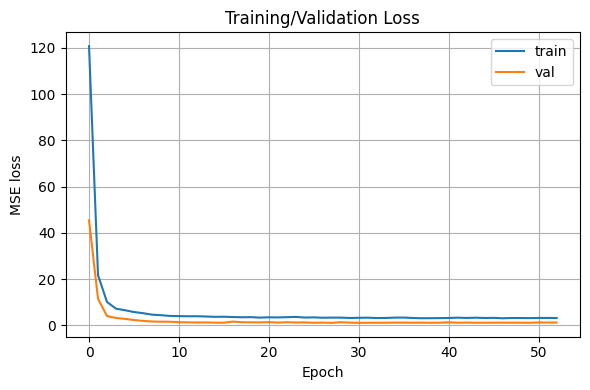

Saved loss plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\plots\loss_curve.png


In [15]:
# Plot loss curves from history
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training/Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
loss_plot_path = PLOTS_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print(f"Saved loss plot to {loss_plot_path}")

In [16]:
# Inspect a few test examples: predictions vs targets
num_examples = 20
indices = torch.arange(min(num_examples, X_test_np.shape[0]))
with torch.no_grad():
    preds = model(torch.from_numpy(X_test_np[indices]).to(device)).squeeze(-1).cpu().numpy()

true_log = y_test_np[indices.numpy()]
results_df = pd.DataFrame(
    {
        "name": test_df.iloc[indices]["name"].values,
        "pred_log_gross": preds,
        "true_log_gross": true_log,
        "delta_log_gross": np.abs(preds - true_log),
        "pred_gross": np.expm1(preds),
        "true_gross": np.expm1(true_log),
        "delta_gross": np.abs(np.expm1(preds) - np.expm1(true_log)),
    }
)

with pd.option_context("display.float_format", "{:.2f}".format):
    display(results_df)

print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

,name,pred_log_gross,true_log_gross,delta_log_gross,pred_gross,true_gross,delta_gross
0,Twilight Zone: The Movie,17.17,17.20,0.03,28514304.00,29450940.00,936636.00
1,No Country for Old Men,18.28,18.96,0.68,87064168.00,171627072.00,84562904.00
2,The Place Beyond the Pines,18.00,17.67,0.33,65713092.00,47052868.00,18660224.00
3,Supercop,14.32,16.60,2.28,1658683.00,16270591.00,14611908.00
4,Zack and Miri Make a Porno,18.28,17.57,0.71,86752368.00,42784308.00,43968060.00
5,The Best of Enemies,16.57,16.14,0.43,15725123.00,10209820.00,5515303.00
6,The Pursuit of D.B. Cooper,14.80,15.12,0.33,2672363.75,3702027.75,1029664.00
7,The Adventures of Tintin,19.65,19.74,0.09,343501216.00,373993856.00,30492640.00
8,The Kiss,13.86,14.44,0.58,1048202.12,1869148.88,820946.75
9,Lethal Weapon 3,19.00,19.59,0.59,177905872.00,321731424.00,143825552.00


Test MSE: 1.0420 | Test MAE: 0.7098


In [ ]:
# Persist artifacts: model, training history, metrics, config, and sample predictions
model_path = CHECKPOINT_DIR / "tabular_regressor.pt"
torch.save({"model_state_dict": model.state_dict(), "config": cfg.__dict__, "input_dim": input_dim}, model_path)
print(f"Saved model to {model_path}")

history_path = RESULTS_DIR / "training_history.csv"
pd.DataFrame(history).to_csv(history_path, index=False)
print(f"Saved training history to {history_path}")

metrics_path = RESULTS_DIR / "test_metrics.csv"
pd.DataFrame([
    {"test_mse": float(test_loss), "test_mae": float(test_mae)}
]).to_csv(metrics_path, index=False)
print(f"Saved test metrics to {metrics_path}")

artifacts_path = RESULTS_DIR / "feature_artifacts.pt"
torch.save(artifacts, artifacts_path)
print(f"Saved feature artifacts to {artifacts_path}")

def _to_jsonable(value):
    import dataclasses
    if dataclasses.is_dataclass(value):
        return dataclasses.asdict(value)
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    if isinstance(value, dict):
        return {k: _to_jsonable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [_to_jsonable(v) for v in value]
    return str(value)

config_path = CONFIG_SNAPSHOT_PATH
serializable_cfg = {k: _to_jsonable(v) for k, v in cfg.__dict__.items()}
serializable_cfg["artifact_root"] = str(ARTIFACT_ROOT)
with config_path.open("w") as f:
    json.dump(serializable_cfg, f, indent=2)
print(f"Saved config to {config_path}")

preds_path = RESULTS_DIR / "sample_predictions.csv"
results_df.to_csv(preds_path, index=False)
print(f"Saved sample predictions to {preds_path}")

Saved model to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\checkpoints\tabular_regressor.pt
Saved training history to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\training_history.csv
Saved test metrics to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\test_metrics.csv
Saved config to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\config.json
Saved sample predictions to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\baseline\results\sample_predictions.csv
